Accuracy: 1.0
w = [0.74136275 0.60219411]
b = -0.060000000000000005


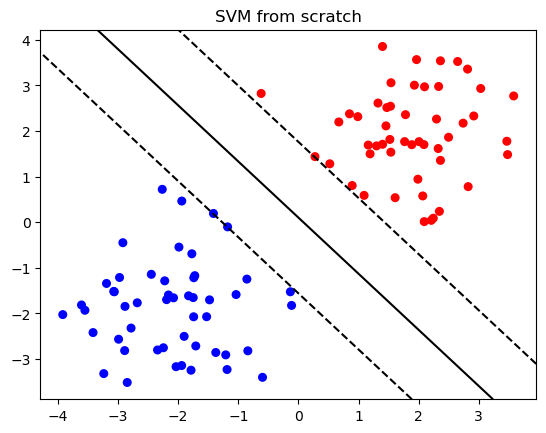

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# data generation
# fixer le hasard pour avoir les mêmes résultats à chaque exécution
np.random.seed(42)
#je veux 100 points de données
n = 100

# class +1 : points autour de (2,2)
X1 = np.random.randn(n//2, 2) + np.array([2, 2])
# tous les points de ce groupe sont de la classe +1
y1 = np.ones(n//2)

# class -1 : points autour de (-2,-2)
X2 = np.random.randn(n//2, 2) + np.array([-2, -2])
# tous ces points appartiennent à la classe négative (-1)
y2 = -np.ones(n//2)

# on regroupe les points dans un seul dataset
X = np.vstack((X1, X2))
# on regroupe les deux classes dans y
y = np.concatenate((y1, y2))

# on transforme les données en tableau (features f1 et f2)
df = pd.DataFrame(X, columns=["f1", "f2"])
# on ajoute la colonne des classes (label)
df["label"] = y

# Séparer les données en ensemble d'entraînement (80%) et de test (20%)
# pour entraîner le modèle sur une partie et évaluer ses performances sur une autre
train = df.sample(frac=0.8, random_state=1)
# Création de l'ensemble de test en supprimant les lignes déjà utilisées dans l'entraînement
# permet d'évaluer le modèle sur des données qu'il n'a jamais vues
test = df.drop(train.index)

# Initialisation des paramètres du modèle (hyperplan)
w = np.zeros(2)
b = 0
# paramètres
learning_rate = 0.01
epochs = 100
lambda_param = 0.01

# prediction function
def predict(x):
    # calcul du score SVM : w.x + b
    result = np.dot(x, w) + b
    # si score positif → classe +1, sinon -1
    return 1 if result >= 0 else -1

# training loop
for _ in range(epochs):
    for _, row in train.iterrows():
        # on récupère les features du point courant
        x = np.array([row["f1"], row["f2"]])
        # on récupère la vraie classe du point
        y_i = row["label"]

        # vérifie si le point est mal classé ou proche de la frontière
        if y_i * (np.dot(x, w) + b) < 1:

            # mise à jour des poids si erreur ou point dans la marge
            # on corrige w pour mieux séparer les classes
            w += learning_rate * (y_i * x - 2 * lambda_param * w)
            #on corrige le bias aussi
            b += learning_rate * y_i

        else:
            # si le point est bien classé
            # on applique seulement la régularisation 
            w += learning_rate * (-2 * lambda_param * w)

# test model
correct = 0

for _, row in test.iterrows():
    
    x = np.array([row["f1"], row["f2"]])
    # prédire la classe avec le modèle SVM
    pred = predict(x)
    # comparer la prédiction avec la vraie valeur
    if pred == row["label"]:
        correct += 1
# calcul de l'accuracy (taux de bonnes prédictions)
accuracy = correct / len(test)
print("Accuracy:", accuracy)

print("w =", w)
print("b =", b)

# affichage des points du dataset (chaque couleur = une classe)
plt.scatter(df["f1"], df["f2"], c=df["label"], cmap="bwr", s=30)

# récupération des limites du graphique pour tracer la frontière
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
# création d'une grille de points pour calculer la frontière de décision
xx = np.linspace(xlim[0], xlim[1], 50)
yy = np.linspace(ylim[0], ylim[1], 50)
YY, XX = np.meshgrid(yy, xx)
# conversion de la grille en liste de points pour calcul SVM
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# calcul du score SVM pour chaque point 
Z = np.dot(xy, w) + b
Z = Z.reshape(XX.shape)

# tracé de la frontière de décision (0) et des marges (-1 et +1)
plt.contour(
    XX, YY, Z,
    levels=[-1, 0, 1],
    colors="black",
    linestyles=["--", "-", "--"]
)

plt.title("SVM from scratch")
plt.show()